# 📊 Bitcoin Fear Greed Trader Analysis

## Objective

The objective of this project is to analyze whether Bitcoin market sentiment (Fear & Greed Index) influences trader behavior and trading performance on the Hyperliquid platform.

The analysis focuses on identifying relationships between market sentiment and key trading metrics such as profitability, trading frequency, trade size, and trading direction. Based on these findings, actionable trading strategies are proposed.

### Importing Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import seaborn as sns
sns.set_theme(style="whitegrid")

### Loading Datasets

In [10]:
fg = pd.read_csv("fear_greed_index.csv")
hist = pd.read_csv("historical_data.csv")

print("Datasets Load Successfully")

Datasets Load Successfully


### Data Overview

Fear & Greed Dataset

In [13]:
fg.shape

(2644, 4)

In [14]:
fg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [16]:
fg.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [17]:
fg.duplicated().sum()

0

In [18]:
fg.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


Historical Trades Dataset

In [20]:
hist.shape

(211224, 16)

In [22]:
hist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [23]:
hist.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [25]:
hist.duplicated().sum()

0

In [26]:
hist.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


### Data Cleaning & Preparation

Convert date columns to datetime format

In [27]:
fg["date"] = pd.to_datetime(fg["date"])

hist["Timestamp IST"] = pd.to_datetime(hist["Timestamp IST"], dayfirst=True)

In [28]:
hist["date"] = hist["Timestamp IST"].dt.normalize()

In [29]:
print("Fear & Greed Date Range")
print(fg["date"].min(), "to", fg["date"].max())

Fear & Greed Date Range
2018-02-01 00:00:00 to 2025-05-02 00:00:00


In [30]:
print("Historical Data Date Range")
print(hist["date"].min(), "to", hist["date"].max())

Historical Data Date Range
2023-05-01 00:00:00 to 2025-05-01 00:00:00


##### Date Range Observation

The Fear & Greed dataset spans from **01-Feb-2018** to **02-May-2025**, while the historical trading dataset spans from **01-May-2023** to **01-May-2025**.

Since the trading data falls completely within the sentiment dataset's date range, the two datasets can be merged using the date column for further analysis.

Merging Datasets

In [31]:
merged_df = pd.merge(hist, fg[["date", "value", "classification"]], on="date", how="left")

In [33]:
merged_df.shape

(211224, 19)

In [35]:
merged_df["classification"].isna().sum()

6

Checking missing dates

In [36]:
missing_dates = merged_df.loc[merged_df["classification"].isna(), "date"].unique()

print(missing_dates)

<DatetimeArray>
['2024-10-26 00:00:00']
Length: 1, dtype: datetime64[ns]


In [39]:
merged_df = merged_df.dropna(subset=["classification"])

In [40]:
merged_df["classification"].isna().sum()

0

In [41]:
merged_df.shape

(211218, 19)

##### Missing Sentiment Records

After merging, 6 trade records did not have a matching market sentiment because the corresponding date was not available in the Fear & Greed dataset.

Since these records represent less than 0.01% of the total data, they were removed to maintain data consistency for the analysis.

#### Feature Engineering

Win/Loss Indicator

In [ ]:
merged_df["Trade Result"] = np.where(
    merged_df["Closed PnL"] > 0, 
    "Win",
    np.where(
        merged_df["Closed PnL"] < 0,
        "Loss",
        "Open / No Realized PnL"
    )
)

In [44]:
merged_df["Trade Result"].value_counts()

Trade Result
Open / No Realized PnL    106816
Win                        86863
Loss                       17539
Name: count, dtype: int64

In [45]:
merged_df["Trade Result"].value_counts(normalize=True) * 100

Trade Result
Open / No Realized PnL    50.571448
Win                       41.124809
Loss                       8.303743
Name: proportion, dtype: float64

Daily PnL

In [48]:
daily_pnl = (merged_df.groupby(["Account", "date", "classification"], as_index=False).agg(
        Daily_PnL=("Closed PnL", "sum"),
        Total_Trades=("Trade ID", "count"),
        Avg_Trade_Size=("Size USD", "mean")))

In [49]:
daily_pnl.head()

,Account,date,classification,Daily_PnL,Total_Trades,Avg_Trade_Size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0,177,5089.718249
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0,68,7976.664412
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0,40,23734.500000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0,12,28186.666667
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1,27,17248.148148


In [ ]:
merged_df.shape

(211218, 19)

Daily Win Rate

In [55]:
merged_df["Win"] = (merged_df["Closed PnL"] > 0).astype(int)

In [62]:
daily_win_rate = (
    merged_df[merged_df["Closed PnL"] != 0].groupby(["Account", "date", "classification"], as_index=False).agg(
        Win_Rate=("Win", "mean")))

daily_win_rate["Win_Rate"] *= 100

In [64]:
daily_win_rate.head()

,Account,date,classification,Win_Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,100.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-28,Extreme Greed,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-12-06,Greed,0.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-19,Extreme Greed,20.535714


Number of trades per day

In [104]:
trades_per_day = (merged_df.groupby(["date", "classification"], as_index=False).agg(
        Total_Trades=("Trade ID", "count")))

In [105]:
trades_per_day.head()

,date,classification,Total_Trades
0,2023-05-01,Greed,3
1,2023-12-05,Extreme Greed,9
2,2023-12-14,Greed,11
3,2023-12-15,Greed,2
4,2023-12-16,Greed,3


Long / Short Counts

In [65]:
long_short = (merged_df.groupby(["classification", "Side"]).size().unstack(fill_value=0))

long_short

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


In [66]:
long_short["Long_Short_Ratio"] = (long_short["BUY"] / long_short["SELL"])

long_short

Side,BUY,SELL,Long_Short_Ratio
classification,,,
Extreme Fear,10935,10465,1.044912
Extreme Greed,17940,22052,0.813532
Fear,30270,31567,0.958913
Greed,24576,25727,0.955261
Neutral,18969,18717,1.013464


### Exploratory Data Analysis

1: Daily PnL by Market Sentiment

In [50]:
sentiment_pnl = (daily_pnl.groupby("classification", as_index=False).agg(
        Average_Daily_PnL=("Daily_PnL", "mean"),
        Median_Daily_PnL=("Daily_PnL", "median"),
        Total_Daily_PnL=("Daily_PnL", "sum")))

In [53]:
sentiment_pnl

,classification,Average_Daily_PnL,Median_Daily_PnL,Total_Daily_PnL
0,Extreme Fear,4619.439053,218.377399,7.391102e+05
1,Extreme Greed,5161.922644,418.319862,2.715171e+06
2,Fear,5328.818161,107.892532,3.357155e+06
3,Greed,3318.100730,158.214922,2.150129e+06
4,Neutral,3438.618818,167.551743,1.292921e+06


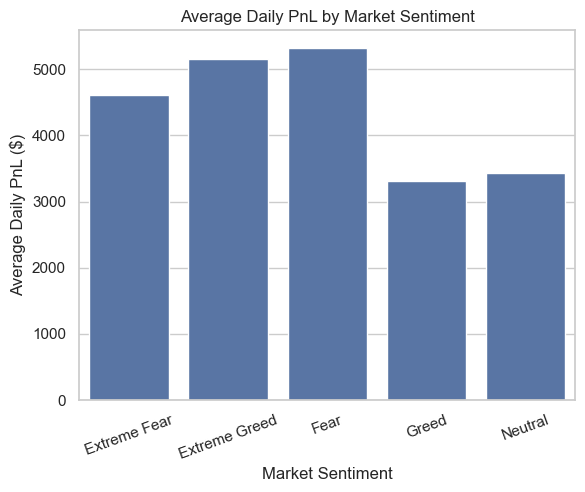

In [52]:
# Visualzie

sns.barplot(data=sentiment_pnl, x="classification", y="Average_Daily_PnL")
plt.title("Average Daily PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Daily PnL ($)")
plt.xticks(rotation=20)
plt.show()

2: Win Rate by Market Sentiment

In [72]:
win_rate_sentiment = (daily_win_rate.groupby("classification", as_index=False).agg(
        Average_Win_Rate=("Win_Rate", "mean")))

win_rate_sentiment

,classification,Average_Win_Rate
0,Extreme Fear,77.153456
1,Extreme Greed,86.788330
2,Fear,86.248765
3,Greed,84.607371
4,Neutral,83.572108


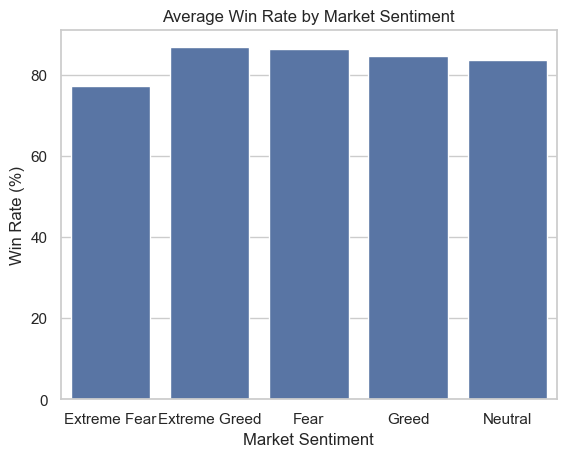

In [ ]:
# Visualzie

sns.barplot(data=win_rate_sentiment,x="classification",y="Average_Win_Rate")
plt.title("Average Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.show()

3: Trade Frequency by Market Sentiment

In [106]:
trade_frequency = (trades_per_day.groupby("classification", as_index=False).agg(
        Average_Trades_Per_Day=("Total_Trades", "mean")))

trade_frequency

,classification,Average_Trades_Per_Day
0,Extreme Fear,1528.571429
1,Extreme Greed,350.807018
2,Fear,679.527473
3,Greed,260.637306
4,Neutral,562.477612


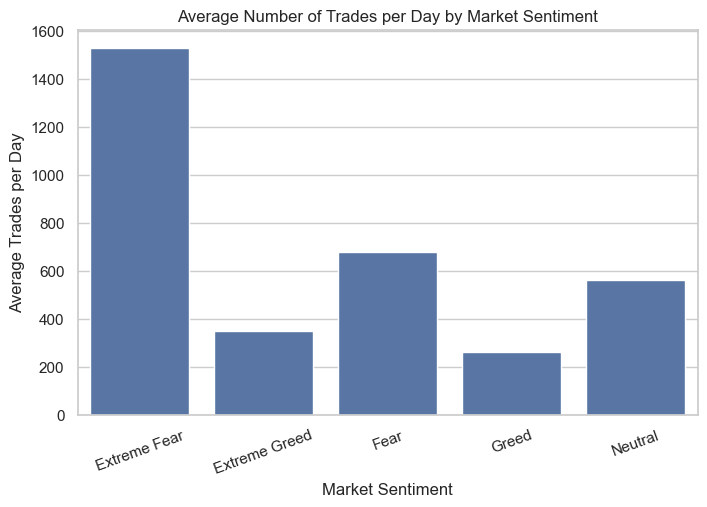

In [ ]:
# Visualzie

plt.figure(figsize=(8,5))
sns.barplot(data=trade_frequency,x="classification",y="Average_Trades_Per_Day")
plt.title("Average Number of Trades per Day by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trades per Day")
plt.xticks(rotation=20)
plt.show()

4: Average Trade Size

In [78]:
trade_size = (merged_df.groupby("classification", as_index=False).agg(
        Average_Trade_Size=("Size USD", "mean"),
        Median_Trade_Size=("Size USD", "median")))

trade_size

,classification,Average_Trade_Size,Median_Trade_Size
0,Extreme Fear,5349.731843,766.150
1,Extreme Greed,3112.251565,500.050
2,Fear,7816.109931,735.960
3,Greed,5736.884375,555.000
4,Neutral,4782.732661,547.655


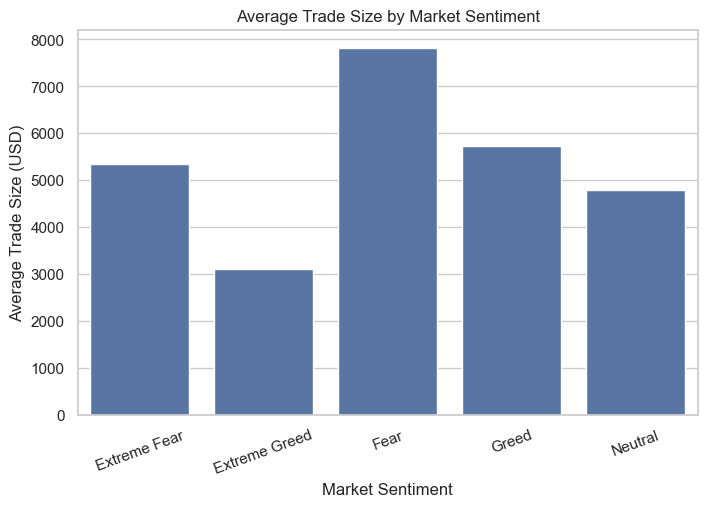

In [79]:
# Visualize

plt.figure(figsize=(8,5))
sns.barplot(data=trade_size, x="classification", y="Average_Trade_Size")
plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=20)
plt.show()

5: Long vs Short Bias

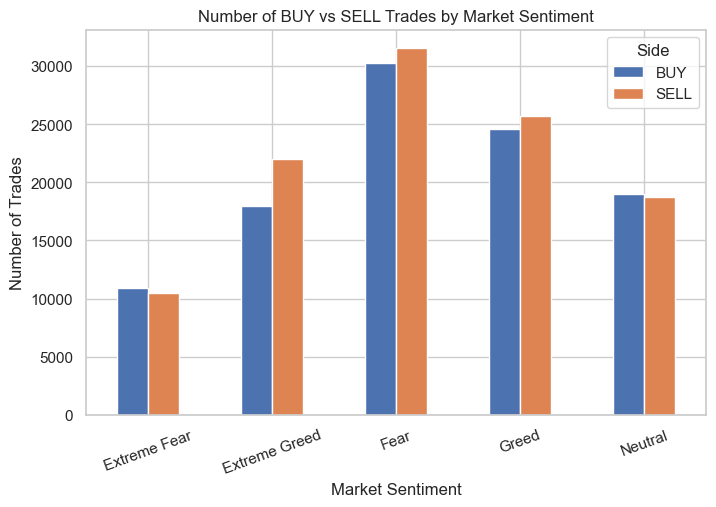

In [80]:
long_short.reset_index().plot(x="classification",y=["BUY", "SELL"],kind="bar",figsize=(8,5))

plt.title("Number of BUY vs SELL Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=20)
plt.show()

Trader-Level Summary

In [ ]:
account_summary = (merged_df.groupby("Account", as_index=False).agg(
        Total_Trades=("Trade ID", "count"),
        Total_PnL=("Closed PnL", "sum"),
        Avg_Trade_Size=("Size USD", "mean"),
        Active_Days=("date", "nunique"),
        Winning_Trades=("Closed PnL", lambda x: (x > 0).sum()),
        Closing_Trades=("Closed PnL", lambda x: (x != 0).sum())))

account_summary.head()

,Account,Total_Trades,Total_PnL,Avg_Trade_Size,Active_Days,Winning_Trades,Closing_Trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,16159.576734,24,1373,1732
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,1653.226327,52,3223,4166
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,8893.000898,12,1150,1607
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,507.626933,162,5838,6772
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,3138.894782,69,1684,2060


In [82]:
# Win Rate
account_summary["Win_Rate"] = (account_summary["Winning_Trades"] / account_summary["Closing_Trades"]) * 100

In [84]:
account_summary["Win_Rate"] = account_summary["Win_Rate"].fillna(0)

Trades per Active Day

In [107]:
account_summary["Trades_Per_Day"] = (account_summary["Total_Trades"] /account_summary["Active_Days"])

In [108]:
account_summary.describe()

,Total_Trades,Total_PnL,Avg_Trade_Size,Active_Days,Winning_Trades,Closing_Trades,Win_Rate,Trades_Per_Day
count,32.000000,3.200000e+01,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,6600.562500,3.204527e+05,6006.264455,73.125000,2714.468750,3262.562500,85.004346,112.585810
std,8250.495093,4.946596e+05,7281.979090,72.726509,3594.133473,4425.653784,11.771499,147.524775
min,332.000000,-1.676211e+05,507.626933,12.000000,90.000000,90.000000,59.902424,11.270270
25%,1377.250000,4.689324e+04,2011.069878,27.500000,520.500000,591.750000,76.036344,33.216667
50%,3699.000000,1.176551e+05,3327.972048,46.500000,1274.500000,1749.500000,84.204149,59.560630
75%,8862.500000,3.884570e+05,7375.525018,74.750000,3399.500000,4495.000000,95.395710,138.671429
max,40184.000000,2.143383e+06,34396.580284,321.000000,17208.000000,22551.000000,100.000000,756.857143


In [ ]:
# Segments

median_trades = account_summary["Total_Trades"].median()
median_win = account_summary["Win_Rate"].median()
median_size = account_summary["Avg_Trade_Size"].median()

In [89]:
# Segment 1: Frequent vs Infrequent

account_summary["Frequency_Segment"] = np.where(
    account_summary["Total_Trades"] >= median_trades,
    "Frequent","Infrequent")

In [90]:
# Segment 2: Consistent vs Inconsistent

account_summary["Winner_Segment"] = np.where(
    account_summary["Win_Rate"] >= median_win,
    "Consistent Winner","Inconsistent Trader")

In [91]:
# Segment 3: Large vs Small Trade Size

account_summary["Size_Segment"] = np.where(
    account_summary["Avg_Trade_Size"] >= median_size,
    "Large Position","Small Position")

In [92]:
account_summary.head()

,Account,Total_Trades,Total_PnL,Avg_Trade_Size,Active_Days,Winning_Trades,Closing_Trades,Win_Rate,Trades_Per_Day,Frequency_Segment,Winner_Segment,Size_Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,16159.576734,24,1373,1732,79.272517,6.628472,Frequent,Inconsistent Trader,Large Position
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,1653.226327,52,3223,4166,77.364378,2.692308,Frequent,Inconsistent Trader,Small Position
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,8893.000898,12,1150,1607,71.561917,26.451389,Frequent,Inconsistent Trader,Large Position
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,507.626933,162,5838,6772,86.207915,0.507202,Frequent,Consistent Winner,Small Position
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,3138.894782,69,1684,2060,81.747573,0.680319,Infrequent,Inconsistent Trader,Small Position


Merging Segments

In [93]:
merged_df = merged_df.merge(account_summary[["Account", "Frequency_Segment", "Winner_Segment", "Size_Segment"]],
    on="Account",how="left")

6: Frequent vs Infrequent Traders

In [94]:
frequency_analysis = (merged_df.groupby(["classification", "Frequency_Segment"],as_index=False).agg(
        Average_PnL=("Closed PnL", "mean"),
        Average_Trade_Size=("Size USD", "mean"),
        Total_Trades=("Trade ID", "count")))

frequency_analysis

,classification,Frequency_Segment,Average_PnL,Average_Trade_Size,Total_Trades
0,Extreme Fear,Frequent,34.163353,5591.430973,16894
1,Extreme Fear,Infrequent,35.941979,4443.547845,4506
2,Extreme Greed,Frequent,62.870911,3115.792937,35020
3,Extreme Greed,Infrequent,103.264685,3087.308111,4972
4,Fear,Frequent,51.323784,8162.301977,55621
5,Fear,Infrequent,80.835791,4718.370584,6216
6,Greed,Frequent,25.004641,5819.243161,45485
7,Greed,Infrequent,210.210287,4959.364790,4818
8,Neutral,Frequent,34.579701,4780.761654,33937
9,Neutral,Infrequent,31.845656,4800.574775,3749


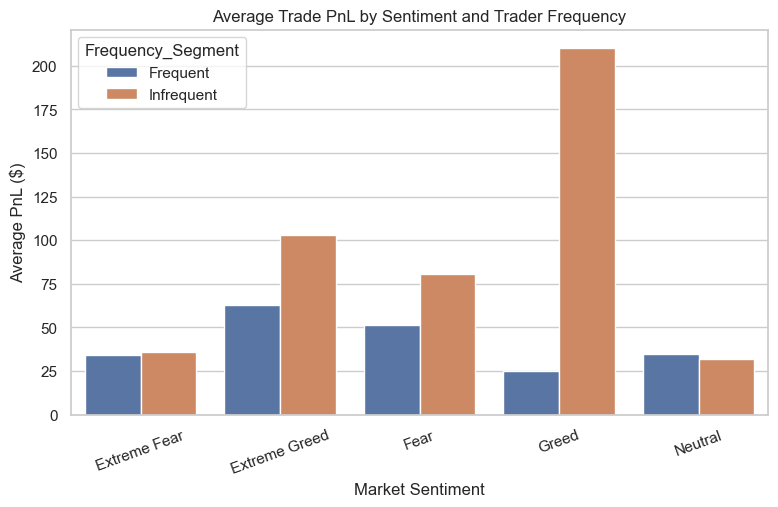

In [95]:
# Visualize

plt.figure(figsize=(9,5))
sns.barplot(data=frequency_analysis, x="classification", y="Average_PnL", hue="Frequency_Segment")
plt.title("Average Trade PnL by Sentiment and Trader Frequency")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL ($)")
plt.xticks(rotation=20)
plt.show()

7: Consistent Winners vs Inconsistent Traders

In [96]:
winner_analysis = (merged_df.groupby(["classification", "Winner_Segment"],as_index=False).agg(
        Average_PnL=("Closed PnL", "mean"),
        Average_Trade_Size=("Size USD", "mean"),
        Total_Trades=("Trade ID", "count")))

winner_analysis

,classification,Winner_Segment,Average_PnL,Average_Trade_Size,Total_Trades
0,Extreme Fear,Consistent Winner,51.424208,5723.820646,8672
1,Extreme Fear,Inconsistent Trader,23.032646,5094.852986,12728
2,Extreme Greed,Consistent Winner,43.848005,3692.482943,20223
3,Extreme Greed,Inconsistent Trader,92.489914,2518.695028,19769
4,Fear,Consistent Winner,51.556183,11215.968890,28087
5,Fear,Inconsistent Trader,56.565835,4986.722121,33750
6,Greed,Consistent Winner,50.822410,9893.771089,19310
7,Greed,Inconsistent Trader,37.710081,3146.961411,30993
8,Neutral,Consistent Winner,40.897906,6461.300033,18314
9,Neutral,Inconsistent Trader,28.077453,3195.840092,19372


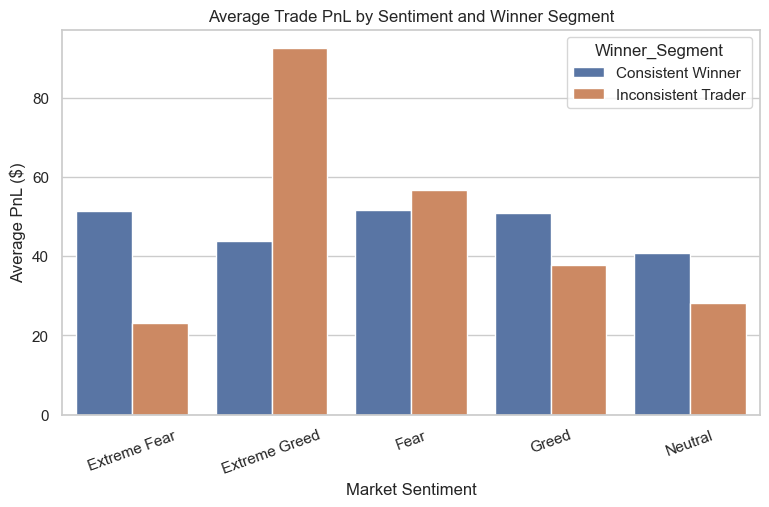

In [98]:
# Visualize

plt.figure(figsize=(9,5))
sns.barplot(data=winner_analysis,x="classification",y="Average_PnL",hue="Winner_Segment")
plt.title("Average Trade PnL by Sentiment and Winner Segment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL ($)")
plt.xticks(rotation=20)
plt.show()

8: Large vs Small Position Traders

In [99]:
size_analysis = (merged_df.groupby(["classification", "Size_Segment"], as_index=False).agg(
        Average_PnL=("Closed PnL", "mean"),
        Average_Trade_Size=("Size USD", "mean"),
        Total_Trades=("Trade ID", "count")))

size_analysis

,classification,Size_Segment,Average_PnL,Average_Trade_Size,Total_Trades
0,Extreme Fear,Large Position,34.584844,9529.281264,8519
1,Extreme Fear,Small Position,34.506790,2585.537951,12881
2,Extreme Greed,Large Position,169.895839,9123.165636,7903
3,Extreme Greed,Small Position,42.771183,1631.860966,32089
4,Fear,Large Position,101.641443,17975.823466,22516
5,Fear,Small Position,27.176235,1998.452446,39321
6,Greed,Large Position,103.165165,14605.356542,16325
7,Greed,Small Position,13.713519,1475.956477,33978
8,Neutral,Large Position,90.484560,12004.611411,11702
9,Neutral,Small Position,9.008249,1530.330217,25984


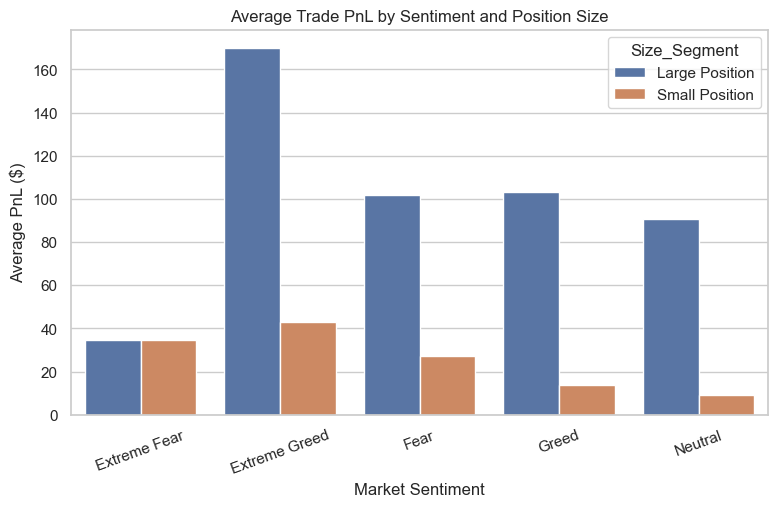

In [101]:
# Visualize

plt.figure(figsize=(9,5))
sns.barplot(data=size_analysis,x="classification",y="Average_PnL",hue="Size_Segment")
plt.title("Average Trade PnL by Sentiment and Position Size")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL ($)")
plt.xticks(rotation=20)
plt.show()

#### Key Insights

Insight 1: Trader performance differs across market sentiment
- Average Daily PnL was highest during Fear and Extreme Greed periods.
- Greed and Neutral markets showed comparatively lower average profitability.
- This suggests that trader performance is influenced by overall market sentiment rather than remaining constant across market conditions.

Insight 2: Trading behavior changes with market sentiment
- Trading activity was highest during Fear periods, indicating increased participation during volatile market conditions.
- Average trade sizes were also larger on Fear days compared to most other sentiment categories.
- The Long/Short ratio varied across sentiment groups, showing that trader positioning changes as market sentiment shifts.

Insight 3: Different trader segments perform differently
- Large Position traders consistently generated higher average PnL than Small Position traders.
- Frequent traders executed significantly more trades but did not always achieve the highest profit per trade.
- Consistent Winners maintained stronger win rates across most market sentiment categories.

#### Strategy Recommendations

Recommendation 1

- During Fear periods, focus on disciplined position sizing instead of simply increasing trading frequency. The analysis shows that larger positions generated stronger average profitability when managed effectively.

Recommendation 2

- During Extreme Greed periods, avoid excessive risk-taking and maintain disciplined position management, as trader performance becomes more variable despite positive market sentiment.

Recommendation 3

- Incorporate the Fear & Greed Index as an additional risk-management signal before entering trades, since both trading behavior and profitability vary across different market sentiment regimes.